In [1]:
import pandas as pd
from statsmodels.regression.linear_model import OLS
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
mlb = pd.read_csv('data/cleaned/mlb.csv')
nfl = pd.read_csv('data/cleaned/nfl.csv')
nhl = pd.read_csv('data/cleaned/nhl.csv')
nba = pd.read_csv('data/cleaned/nba.csv')

Hypothesis 1

In [3]:
mlb

,Unnamed: 0,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,...,pitcher1_adj,pitcher2_adj,rating_prob1,rating_prob2,rating1_post,rating2_post,score1,score2,win1,win2
0,8316,2019-10-30,2019,0,w,HOU,WSN,1599.542804,1584.363378,0.574617,...,0.989236,27.776342,0.515172,0.484828,1587.973463,1583.382133,2.0,6.0,False,True
1,8317,2019-10-29,2019,0,w,HOU,WSN,1605.069000,1578.837182,0.595209,...,28.723451,21.776276,0.594638,0.405362,1591.026009,1580.329587,2.0,7.0,False,True
2,8318,2019-10-27,2019,0,w,WSN,HOU,1584.005206,1599.900976,0.515546,...,-29.811205,47.888341,0.373102,0.626898,1576.189971,1595.165625,1.0,7.0,False,True
3,8319,2019-10-26,2019,0,w,WSN,HOU,1589.985555,1593.920627,0.538425,...,0.823752,-24.893480,0.586974,0.413026,1578.722119,1592.633477,1.0,8.0,False,True
4,8320,2019-10-25,2019,0,w,WSN,HOU,1593.827376,1590.078806,0.553044,...,-9.053908,2.440389,0.526852,0.473148,1583.715416,1587.640180,1.0,4.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71083,79399,1990-04-09,1990,0,r1,KCR,BAL,1520.125000,1500.548000,0.562386,...,-1.324502,1.921183,0.562594,0.437406,1515.269000,1502.213000,6.0,7.0,False,True
71084,79400,1990-04-09,1990,0,r1,HOU,CIN,1504.135000,1492.159000,0.551589,...,-0.282179,2.193646,0.553622,0.446378,1499.186000,1495.150000,4.0,8.0,False,True
71085,79401,1990-04-09,1990,0,r1,CHW,MIL,1491.470000,1516.772000,0.498126,...,0.537577,-3.098140,0.500440,0.499560,1493.860000,1515.854000,2.0,1.0,True,False
71086,79402,1990-04-09,1990,0,r1,BOS,DET,1519.201000,1462.610000,0.613943,...,0.532024,-4.070484,0.618117,0.381883,1519.587000,1459.984000,5.0,2.0,True,False


In [4]:
mlb_first_half = mlb[mlb.playoff == 'r1'][['playoff','team1','team2','win1', 'win2', 'season']]
mlb_second_half = mlb[mlb.playoff == 'r2'][['playoff','team1','team2','win1', 'win2', 'season']]

team1_first = mlb_first_half[['team1','win1', 'win2', 'season']].groupby(by=['team1', 'season']).mean()[['win1']]

team2_first = mlb_first_half[['team2','win1', 'win2', 'season']].groupby(by=['team2', 'season']).mean()[['win2']]

team1_second = mlb_second_half[['team1','win1', 'win2', 'season']].groupby(by=['team1', 'season']).mean()[['win1']]

team2_second = mlb_second_half[['team2','win1', 'win2', 'season']].groupby(by=['team2', 'season']).mean()[['win2']]

mlb_first_half = []
mlb_second_half = []

for entry in team2_second.index:
  mlb_first_half.append(
    (team1_first.loc[entry][0] + team2_first.loc[entry][0])/2)
  mlb_second_half.append(
    (team1_second.loc[entry][0] + team2_second.loc[entry][0])/2)

In [5]:
nfl

,Unnamed: 0,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,...,qb2_value_post,qbelo1_post,qbelo2_post,score1,score2,quality,importance,total_rating,win1,win2
0,8772,1990-01-06,1989,0,d,SF,MIN,1741.063000,1595.514000,0.770656,...,51.725553,1754.600057,1593.030336,41,13,99.0,NaN,NaN,True,False
1,8773,1990-01-06,1989,0,d,CLE,BUF,1565.876000,1576.806000,0.577191,...,108.600079,1585.435143,1557.860251,34,30,82.0,NaN,NaN,True,False
2,8774,1990-01-07,1989,0,d,DEN,PIT,1599.653000,1556.821000,0.650385,...,26.379709,1609.115584,1558.557946,24,23,85.0,NaN,NaN,True,False
3,8775,1990-01-07,1989,0,d,NYG,LAR,1623.766000,1643.646000,0.564570,...,143.606274,1605.143784,1658.272653,13,19,95.0,NaN,NaN,False,True
4,8776,1990-01-14,1989,0,c,SF,LAR,1755.160000,1666.078000,0.708264,...,116.263872,1768.310856,1644.561854,30,3,100.0,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7753,16525,2019-12-29,2019,0,r2,HOU,TEN,1584.215388,1542.863113,0.648445,...,181.942757,1548.822776,1554.769316,14,35,45.0,NaN,NaN,False,True
7754,16526,2019-12-29,2019,0,r2,DEN,OAK,1487.042014,1407.432240,0.696871,...,189.272692,1505.095626,1404.638088,16,15,27.0,NaN,NaN,True,False
7755,16527,2019-12-29,2019,0,r2,DAL,WSH,1536.023522,1309.885760,0.842364,...,108.936558,1525.722911,1297.390156,47,16,12.0,NaN,NaN,True,False
7756,16528,2019-12-29,2019,0,r2,NYG,PHI,1351.254830,1551.327497,0.314850,...,196.359221,1337.144094,1567.090802,17,34,24.0,NaN,NaN,False,True


In [6]:
nfl_first_half = nfl[nfl.playoff == 'r1'][['playoff','team1','team2','win1', 'win2', 'season']]
nfl_second_half = nfl[nfl.playoff == 'r2'][['playoff','team1','team2','win1', 'win2', 'season']]

team1_first = nfl_first_half[['team1','win1', 'win2', 'season']].groupby(by=['team1', 'season']).mean()[['win1']]

team2_first = nfl_first_half[['team2','win1', 'win2', 'season']].groupby(by=['team2', 'season']).mean()[['win2']]

team1_second = nfl_second_half[['team1','win1', 'win2', 'season']].groupby(by=['team1', 'season']).mean()[['win1']]

team2_second = nfl_second_half[['team2','win1', 'win2', 'season']].groupby(by=['team2', 'season']).mean()[['win2']]


In [7]:
intersection = team2_second.index.intersection(team1_second.index)\
  .intersection(team2_first.index)\
  .intersection(team1_first.index)

In [8]:
nfl_first_half = []
nfl_second_half = []

for entry in intersection:
  nfl_first_half.append(
    (team1_first.loc[entry][0] + team2_first.loc[entry][0])/2)
  nfl_second_half.append(
    (team1_second.loc[entry][0] + team2_second.loc[entry][0])/2)

In [9]:
nba

,Unnamed: 0,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,...,raptor2_pre,raptor_prob1,raptor_prob2,score1,score2,quality,importance,total_rating,win1,win2
0,31335,1990-01-02,1990,0,r2,NYK,PHO,1620.015700,1565.457600,0.708830,...,NaN,NaN,NaN,99,113,84,NaN,NaN,False,True
1,31336,1990-01-02,1990,0,r2,WSB,NJN,1466.478800,1325.255500,0.800368,...,NaN,NaN,NaN,110,96,8,NaN,NaN,True,False
2,31337,1990-01-02,1990,0,r2,POR,MIA,1527.168300,1263.916600,0.890030,...,NaN,NaN,NaN,119,95,6,NaN,NaN,True,False
3,31338,1990-01-02,1990,0,r2,ATL,MIL,1545.971100,1527.273700,0.664470,...,NaN,NaN,NaN,113,107,63,NaN,NaN,True,False
4,31339,1990-01-02,1990,0,r2,DAL,IND,1457.774900,1528.762500,0.541655,...,NaN,NaN,NaN,110,106,43,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37569,68904,2019-12-31,2020,0,r1,SAC,LAC,1439.142942,1631.787446,0.369746,...,1673.642954,0.356105,0.643895,87,105,78,NaN,NaN,False,True
37570,68905,2019-12-31,2020,0,r1,HOU,DEN,1629.924907,1618.388168,0.655218,...,1619.552957,0.660334,0.339666,130,104,91,NaN,NaN,True,False
37571,68906,2019-12-31,2020,0,r1,TOR,CLE,1642.844707,1341.079149,0.909927,...,1367.542051,0.853411,0.146589,117,97,36,NaN,NaN,True,False
37572,68907,2019-12-31,2020,0,r1,SAS,GSW,1484.142262,1412.580576,0.728611,...,1362.597654,0.701361,0.298639,117,113,11,NaN,NaN,True,False


In [10]:
nba_first_half = nba[nba.playoff == 'r1'][['playoff','team1','team2','win1', 'win2', 'season']]
nba_second_half = nba[nba.playoff == 'r2'][['playoff','team1','team2','win1', 'win2', 'season']]

team1_first = nba_first_half[['team1','win1', 'win2', 'season']].groupby(by=['team1', 'season']).mean()[['win1']]

team2_first = nba_first_half[['team2','win1', 'win2', 'season']].groupby(by=['team2', 'season']).mean()[['win2']]

team1_second = nba_second_half[['team1','win1', 'win2', 'season']].groupby(by=['team1', 'season']).mean()[['win1']]

team2_second = nba_second_half[['team2','win1', 'win2', 'season']].groupby(by=['team2', 'season']).mean()[['win2']]


In [11]:
intersection = team2_second.index.intersection(team1_second.index)\
  .intersection(team2_first.index)\
  .intersection(team1_first.index)

In [12]:
nba_first_half = []
nba_second_half = []

for entry in intersection:
  nba_first_half.append(
    (team1_first.loc[entry][0] + team2_first.loc[entry][0])/2)
  nba_second_half.append(
    (team1_second.loc[entry][0] + team2_second.loc[entry][0])/2)

In [13]:
nhl

,Unnamed: 0,season,date,playoff,neutral,status,ot,home_team,away_team,home_team_abbr,...,away_team_expected_points,home_team_score,away_team_score,home_team_postgame_rating,away_team_postgame_rating,game_quality_rating,game_importance_rating,game_overall_rating,win1,win2
0,26609,1990,1990-01-01,r2,0,post,NaN,Washington Capitals,Los Angeles Kings,WSH,...,0.985943,4,7,1529.477684,1538.299971,82,NaN,NaN,False,True
1,26610,1990,1990-01-02,r2,0,post,NaN,St. Louis Blues,Edmonton Oilers,STL,...,1.158446,4,6,1486.878422,1559.089837,70,NaN,NaN,False,True
2,26611,1990,1990-01-02,r2,0,post,OT,Calgary Flames,Philadelphia Flyers,CGY,...,0.846386,4,4,1592.644361,1536.641035,98,NaN,NaN,False,False
3,26612,1990,1990-01-02,r2,0,post,NaN,New Jersey Devils,Buffalo Sabres,NJD,...,1.126862,5,3,1490.253388,1534.629366,56,NaN,NaN,True,False
4,26613,1990,1990-01-02,r2,0,post,NaN,New York Islanders,Los Angeles Kings,NYI,...,1.170596,5,3,1472.400894,1534.237339,43,NaN,NaN,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35164,61773,2020,2019-12-31,r1,0,post,NaN,Calgary Flames,Chicago Blackhawks,CGY,...,0.916375,3,5,1503.333272,1483.765572,32,NaN,NaN,False,True
35165,61774,2020,2019-12-31,r1,0,post,NaN,Carolina Hurricanes,Montreal Canadiens,CAR,...,0.905500,3,1,1545.008456,1505.849080,73,NaN,NaN,True,False
35166,61775,2020,2019-12-31,r1,0,post,NaN,Buffalo Sabres,Tampa Bay Lightning,BUF,...,1.269490,4,6,1448.440289,1565.333949,47,NaN,NaN,False,True
35167,61776,2020,2019-12-31,r1,0,post,NaN,Arizona Coyotes,St. Louis Blues,ARI,...,1.168689,3,1,1498.991525,1560.066762,77,NaN,NaN,True,False


In [14]:
nhl_first_half = nhl[nhl.playoff == 'r1'][['playoff','home_team','away_team','win1', 'win2', 'season']]
nhl_second_half = nhl[nhl.playoff == 'r2'][['playoff','home_team','away_team','win1', 'win2', 'season']]

team1_first = nhl_first_half[['home_team','win1', 'win2', 'season']].groupby(by=['home_team', 'season']).mean()[['win1']]

team2_first = nhl_first_half[['away_team','win1', 'win2', 'season']].groupby(by=['away_team', 'season']).mean()[['win2']]

team1_second = nhl_second_half[['home_team','win1', 'win2', 'season']].groupby(by=['home_team', 'season']).mean()[['win1']]

team2_second = nhl_second_half[['away_team','win1', 'win2', 'season']].groupby(by=['away_team', 'season']).mean()[['win2']]


In [15]:
intersection = team2_second.index.intersection(team1_second.index)\
  .intersection(team2_first.index)\
  .intersection(team1_first.index)

In [16]:
nhl_first_half = []
nhl_second_half = []

for entry in intersection:
  nhl_first_half.append(
    (team1_first.loc[entry][0] + team2_first.loc[entry][0])/2)
  nhl_second_half.append(
    (team1_second.loc[entry][0] + team2_second.loc[entry][0])/2)

In [25]:
second_half = mlb_second_half + nfl_second_half + nba_second_half + nhl_second_half
first_half = mlb_first_half + nfl_first_half + nba_first_half + nhl_first_half

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.903
Model:                            OLS   Adj. R-squared (uncentered):              0.903
Method:                 Least Squares   F-statistic:                          3.135e+04
Date:                Thu, 16 Nov 2023   Prob (F-statistic):                        0.00
Time:                        09:00:41   Log-Likelihood:                          1356.1
No. Observations:                3357   AIC:                                     -2710.
Df Residuals:                    3356   BIC:                                     -2704.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.9513      0.005    177.068      0.000       0.941       0.962
==============================================================================
Omnibus:                      199.617   Durbin-Watson:                   1.921
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              855.787
Skew:                           0.026   Prob(JB):                    1.47e-186
Kurtosis:                       5.473   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

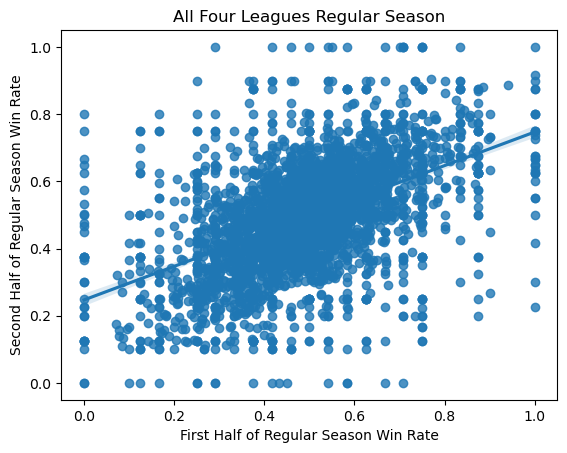

In [26]:
sns.regplot(y=second_half, x=first_half)
plt.xlabel('First Half of Regular Season Win Rate')
plt.ylabel('Second Half of Regular Season Win Rate')
plt.title('All Four Leagues Regular Season')
plt.plot()

model = OLS(endog=second_half, exog=first_half, hasconst=False)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.942
Model:                            OLS   Adj. R-squared (uncentered):              0.942
Method:                 Least Squares   F-statistic:                          1.327e+04
Date:                Thu, 16 Nov 2023   Prob (F-statistic):                        0.00
Time:                        09:01:29   Log-Likelihood:                          525.24
No. Observations:                 812   AIC:                                     -1048.
Df Residuals:                     811   BIC:                                     -1044.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.9717      0.008    115.205      0.000       0.955       0.988
==============================================================================
Omnibus:                        9.962   Durbin-Watson:                   1.901
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               12.122
Skew:                           0.163   Prob(JB):                      0.00233
Kurtosis:                       3.502   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

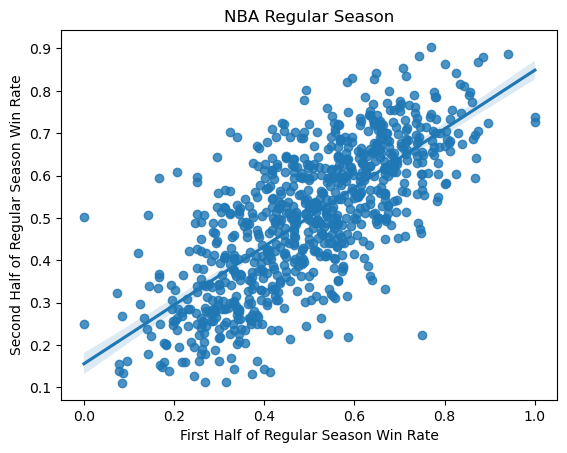

In [27]:
sns.regplot(y=nba_second_half, x=nba_first_half)
plt.xlabel('First Half of Regular Season Win Rate')
plt.ylabel('Second Half of Regular Season Win Rate')
plt.title('NBA Regular Season')
plt.plot()

model = OLS(endog=nba_second_half, exog=nba_first_half, hasconst=False)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.974
Model:                            OLS   Adj. R-squared (uncentered):              0.974
Method:                 Least Squares   F-statistic:                          3.294e+04
Date:                Thu, 16 Nov 2023   Prob (F-statistic):                        0.00
Time:                        09:01:49   Log-Likelihood:                          953.35
No. Observations:                 878   AIC:                                     -1905.
Df Residuals:                     877   BIC:                                     -1900.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.9900      0.005    181.493      0.000       0.979       1.001
==============================================================================
Omnibus:                        0.472   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.790   Jarque-Bera (JB):                0.536
Skew:                           0.051   Prob(JB):                        0.765
Kurtosis:                       2.936   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

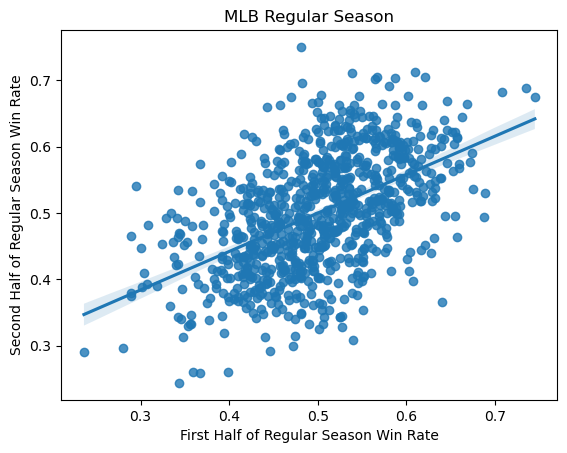

In [28]:
sns.regplot(y=mlb_second_half, x=mlb_first_half)
plt.xlabel('First Half of Regular Season Win Rate')
plt.ylabel('Second Half of Regular Season Win Rate')
plt.title('MLB Regular Season')
plt.plot()

model = OLS(endog=mlb_second_half, exog=mlb_first_half, hasconst=False)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.945
Model:                            OLS   Adj. R-squared (uncentered):              0.945
Method:                 Least Squares   F-statistic:                          1.256e+04
Date:                Thu, 16 Nov 2023   Prob (F-statistic):                        0.00
Time:                        09:03:09   Log-Likelihood:                          554.36
No. Observations:                 738   AIC:                                     -1107.
Df Residuals:                     737   BIC:                                     -1102.
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.9765      0.009    112.082      0.000       0.959       0.994
==============================================================================
Omnibus:                        0.638   Durbin-Watson:                   1.933
Prob(Omnibus):                  0.727   Jarque-Bera (JB):                0.564
Skew:                           0.066   Prob(JB):                        0.754
Kurtosis:                       3.033   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

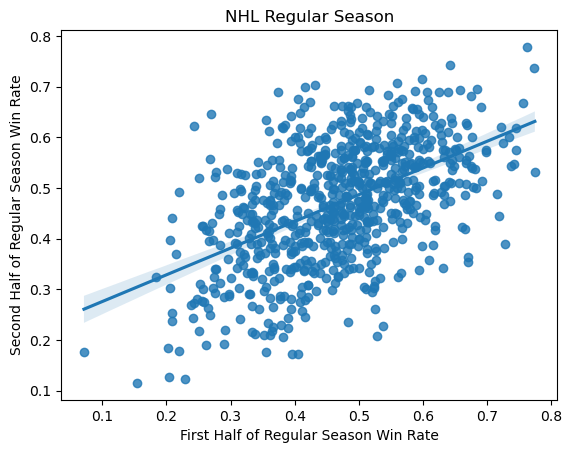

In [29]:
sns.regplot(y=nhl_second_half, x=nhl_first_half)
plt.xlabel('First Half of Regular Season Win Rate')
plt.ylabel('Second Half of Regular Season Win Rate')
plt.title('NHL Regular Season')
plt.plot()

model = OLS(endog=nhl_second_half, exog=nhl_first_half, hasconst=False)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                      y   R-squared (uncentered):                   0.795
Model:                            OLS   Adj. R-squared (uncentered):              0.795
Method:                 Least Squares   F-statistic:                              3598.
Date:                Thu, 16 Nov 2023   Prob (F-statistic):                   1.43e-321
Time:                        09:03:31   Log-Likelihood:                         -25.464
No. Observations:                 929   AIC:                                      52.93
Df Residuals:                     928   BIC:                                      57.76
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.8888      0.015     59.984      0.000       0.860       0.918
==============================================================================
Omnibus:                        0.029   Durbin-Watson:                   1.884
Prob(Omnibus):                  0.986   Jarque-Bera (JB):                0.066
Skew:                           0.010   Prob(JB):                        0.968
Kurtosis:                       2.964   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

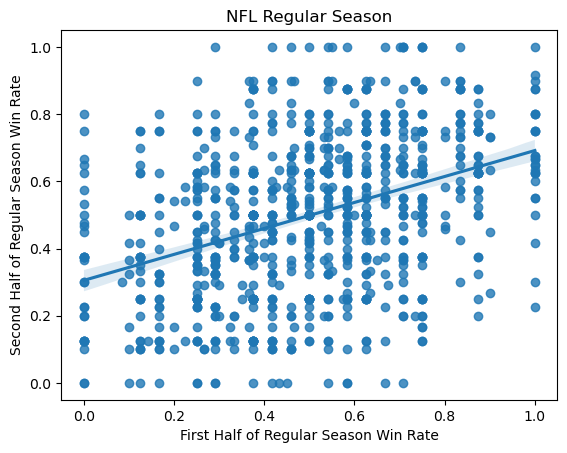

In [30]:
sns.regplot(y=nfl_second_half, x=nfl_first_half)
plt.xlabel('First Half of Regular Season Win Rate')
plt.ylabel('Second Half of Regular Season Win Rate')
plt.title('NFL Regular Season')
plt.plot()

model = OLS(endog=nfl_second_half, exog=nfl_first_half, hasconst=False)
results = model.fit()
results.summary()

In [34]:
nba_first_half = np.array(nba_first_half)
nba_second_half = np.array(nba_second_half)

mlb_first_half = np.array(mlb_first_half)
mlb_second_half = np.array(mlb_second_half)

nhl_first_half = np.array(nhl_first_half)
nhl_second_half = np.array(nhl_second_half)

nfl_first_half = np.array(nfl_first_half)
nfl_second_half = np.array(nfl_second_half)

In [51]:
def single_bootstrap(l1, l2):
  boot1 = np.zeros(1000)
  boot2 = np.zeros(1000)
  for i in range(1000):
    boot1[i] = np.random.choice(l1, size=len(l1), replace=True).mean()
    boot2[i] = np.random.choice(l2, size=len(l2), replace=True).mean()
  return  boot1 - boot2

nba_mlb_first = single_bootstrap(nba_first_half, mlb_first_half)
nba_mlb_second = single_bootstrap(nba_second_half, mlb_second_half)

nba_nhl_first  = single_bootstrap(nba_first_half, nhl_first_half)
nba_nhl_second = single_bootstrap(nba_second_half, nhl_second_half)


nba_nfl_first = single_bootstrap(nba_first_half, nfl_first_half)
nba_nfl_second = single_bootstrap(nba_second_half, nfl_second_half)

mlb_nhl_first = single_bootstrap(mlb_first_half, nhl_first_half)
mlb_nhl_second = single_bootstrap(mlb_second_half, nhl_second_half)

mlb_nfl_first = single_bootstrap(mlb_first_half, nfl_first_half)
mlb_nfl_second = single_bootstrap(mlb_second_half, nfl_second_half)

nhl_nfl_first = single_bootstrap(nhl_first_half, nfl_first_half)
nhl_nfl_second = single_bootstrap(nhl_second_half, nfl_second_half)

In [49]:
true_nba_mlb_first = nba_first_half.mean() - mlb_first_half.mean()
true_nba_mlb_second = nba_second_half.mean() - mlb_second_half.mean()

true_nba_nhl_first  = nba_first_half.mean() - nhl_first_half.mean()
true_nba_nhl_second = nba_second_half.mean() - nhl_second_half.mean()


true_nba_nfl_first = nba_first_half.mean() - nfl_first_half.mean()
true_nba_nfl_second = nba_second_half.mean() - nfl_second_half.mean()

true_mlb_nhl_first = mlb_first_half.mean() - nhl_first_half.mean()
true_mlb_nhl_second = mlb_second_half.mean() - nhl_second_half.mean()

true_mlb_nfl_first = mlb_first_half.mean() - nfl_first_half.mean()
true_mlb_nfl_second = mlb_second_half.mean() - nfl_second_half.mean()

true_nhl_nfl_first = nhl_first_half.mean() - nfl_first_half.mean()
true_nhl_nfl_second = nhl_second_half.mean() - nfl_second_half.mean()

In [69]:
def significance_test(boot, true, name):
  pvalue = (boot > true).mean()
  sig = '*** ' if pvalue < 0.001 else \
        '**  ' if pvalue < 0.01 else \
        '*   ' if pvalue < 0.05 else '   '
  print(f'{sig} {name} -> {pvalue.round(5)}')
  return None

In [75]:
tests = [
  (nba_mlb_first, true_nba_mlb_first, 'First Half NBA MLB'),
  (nba_mlb_second, true_nba_mlb_second, 'Second Half NBA MLB'),
  (nba_nhl_first, true_nba_nhl_first, 'First Half NBA NHL'),
  (nba_nhl_second, true_nba_nhl_second, 'Second Half NBA NHL'),
  (nba_nfl_first, true_nba_nfl_first, 'First Half NBA NFL'),
  (nba_nfl_second, true_nba_nfl_second, 'Second Half NBA NFL'),

  (mlb_nhl_first, true_mlb_nhl_first, 'First Half MLB NHL'),
  (mlb_nhl_second, true_mlb_nhl_second, 'Second Half MLB NHL'),
  (mlb_nfl_first, true_mlb_nfl_first, 'First Half MLB NFL'),
  (mlb_nfl_second, true_mlb_nfl_second, 'Second Half MLB NFL'),

  (nhl_nfl_first, true_nhl_nfl_first, 'First Half NHL NFL'),
  (nhl_nfl_second, true_nhl_nfl_second, 'Second Half NHL NFL'),
]
print('Significance tests')
print('sig -------test-------    pvalue')
[significance_test(boot, true, name) for (boot, true, name) in tests]


Significance tests
sig -------test-------    pvalue
    First Half NBA MLB -> 0.497
    Second Half NBA MLB -> 0.5
    First Half NBA NHL -> 0.505
    Second Half NBA NHL -> 0.472
    First Half NBA NFL -> 0.486
    Second Half NBA NFL -> 0.518
    First Half MLB NHL -> 0.507
    Second Half MLB NHL -> 0.503
    First Half MLB NFL -> 0.516
    Second Half MLB NFL -> 0.511
    First Half NHL NFL -> 0.506
    Second Half NHL NFL -> 0.469


[None, None, None, None, None, None, None, None, None, None, None, None]